# Dynamic Product Pricing Using RNN

### Importing necessary libraries

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the dataset

In [7]:
df=pd.read_csv(r"C:\Users\Waheed Bepari\OneDrive\Desktop\DATA SCIENCE COURSE\DEEP LEARNING + AI\sales_data.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


### Dataset information

In [8]:
# checks the columns, datatypes and missing values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

### Dataset size

In [9]:
#checks number of rows and columns

df.shape

(76000, 16)

### Data Preprocessing
#### Check missing values, duplicates and basic statistical information.

In [10]:
df.isna().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [11]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


In [12]:
df['Price'].describe()

count    76000.000000
mean        67.726028
std         39.377899
min          4.740000
25%         31.997500
50%         64.500000
75%         95.830000
max        228.030000
Name: Price, dtype: float64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Date'].head()

0    2022-01-01
1    2022-01-01
2    2022-01-01
3    2022-01-01
4    2022-01-01
Name: Date, dtype: object

In [15]:
df['Date'].dtype

dtype('O')

### Product and Store Analysis
#### Check the number of products, stores and their available records.

In [16]:
df['Product ID'].nunique()

20

In [17]:
df['Store ID'].nunique()

5

In [18]:
df['Product ID'].value_counts().head()

Product ID
P0001    3800
P0002    3800
P0019    3800
P0018    3800
P0017    3800
Name: count, dtype: int64

In [19]:
df['Store ID'].value_counts()

Store ID
S001    15200
S002    15200
S003    15200
S004    15200
S005    15200
Name: count, dtype: int64

### Data preparation

In [20]:
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
df = df.sort_values('Date')

In [22]:
df = df.reset_index(drop=True)

### Exploratory Data Analysis (EDA)

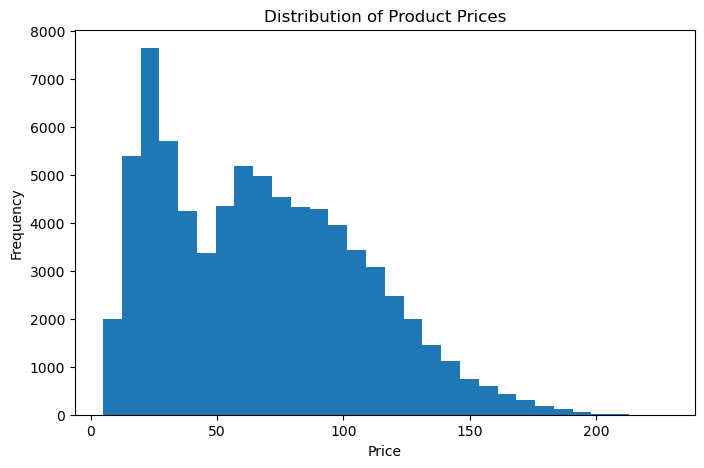

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df['Price'], bins=30)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Product Prices')

plt.show()

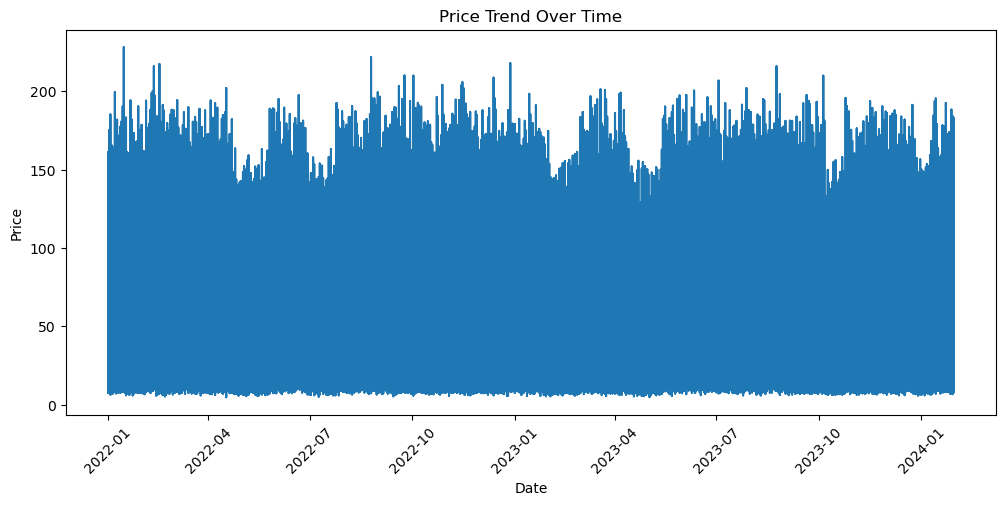

In [24]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Price'])

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Price Trend Over Time')

plt.xticks(rotation=45)

plt.show()

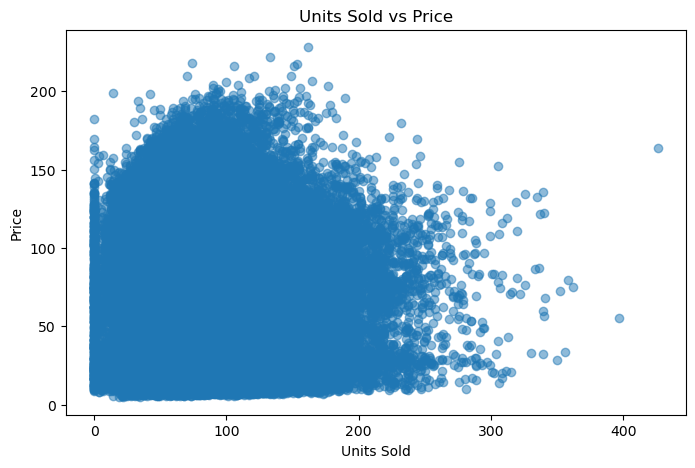

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(df['Units Sold'], df['Price'], alpha=0.5)

plt.xlabel('Units Sold')
plt.ylabel('Price')
plt.title('Units Sold vs Price')

plt.show()

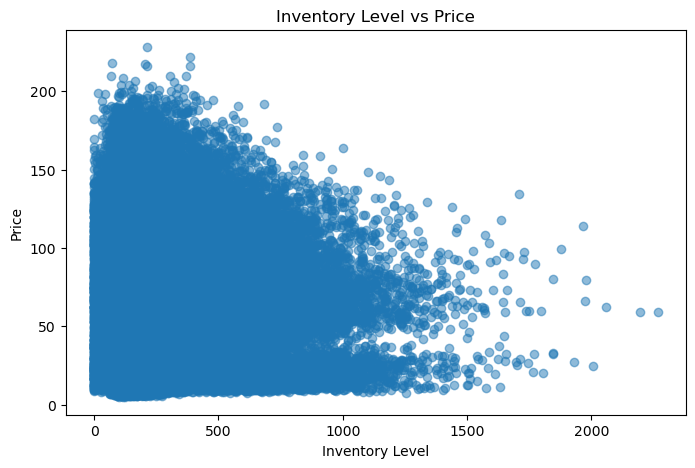

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(df['Inventory Level'], df['Price'], alpha=0.5)

plt.xlabel('Inventory Level')
plt.ylabel('Price')
plt.title('Inventory Level vs Price')

plt.show()

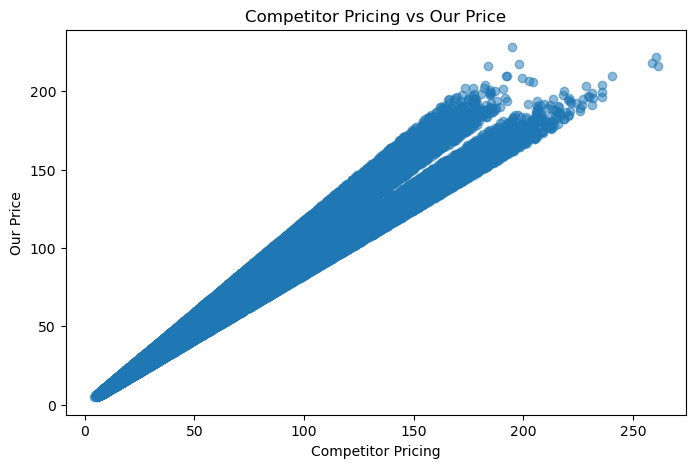

In [27]:
plt.figure(figsize=(8,5))

plt.scatter(df['Competitor Pricing'], df['Price'], alpha=0.5)

plt.xlabel('Competitor Pricing')
plt.ylabel('Our Price')
plt.title('Competitor Pricing vs Our Price')

plt.show()

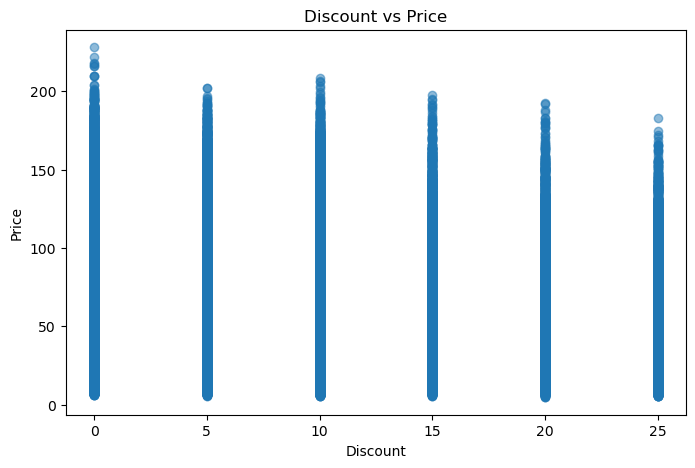

In [28]:
plt.figure(figsize=(8,5))

plt.scatter(df['Discount'], df['Price'], alpha=0.5)

plt.xlabel('Discount')
plt.ylabel('Price')
plt.title('Discount vs Price')

plt.show()

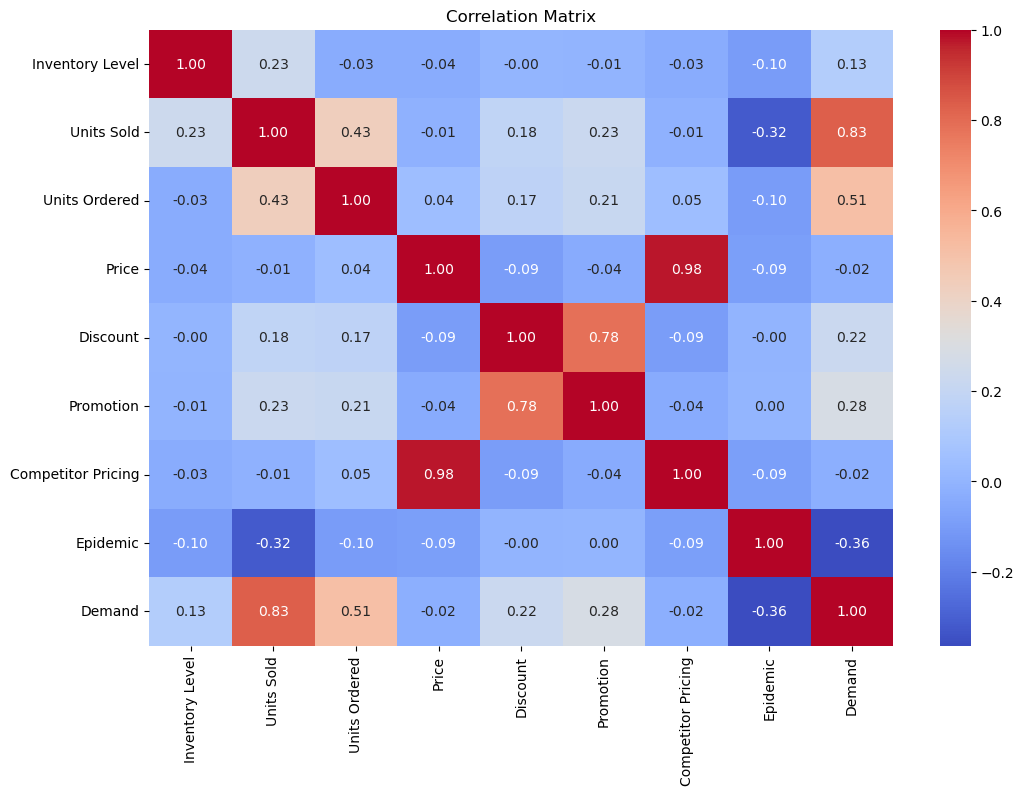

In [29]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')

plt.show()

In [30]:
df['Promotion'].value_counts()

Promotion
0    51000
1    25000
Name: count, dtype: int64

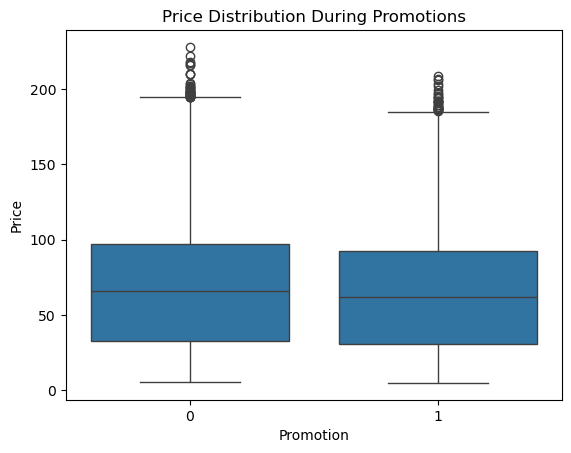

In [31]:
sns.boxplot(x='Promotion', y='Price', data=df)

plt.title('Price Distribution During Promotions')
plt.show()

In [32]:
df['Seasonality'].value_counts()

Seasonality
Winter    21000
Spring    18400
Summer    18400
Autumn    18200
Name: count, dtype: int64

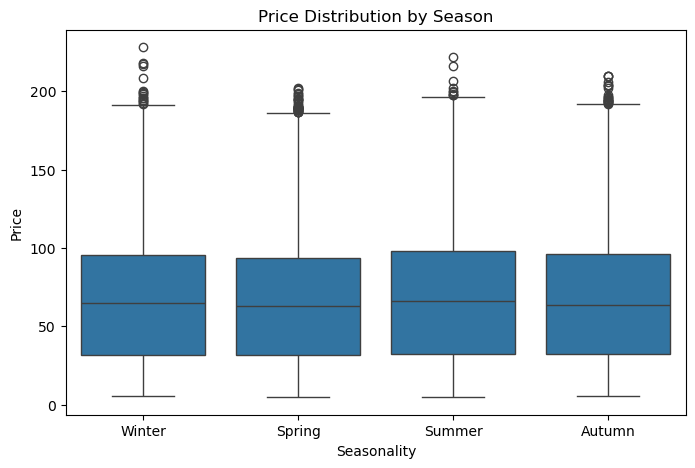

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Seasonality',
    y='Price',
    data=df
)

plt.title('Price Distribution by Season')

plt.show()

In [34]:
df.groupby(['Store ID', 'Product ID']).size().describe()

count    100.0
mean     760.0
std        0.0
min      760.0
25%      760.0
50%      760.0
75%      760.0
max      760.0
dtype: float64

In [35]:
df.groupby(['Store ID', 'Product ID']).size().sort_values().head(10)

Store ID  Product ID
S001      P0001         760
S004      P0013         760
          P0012         760
          P0011         760
          P0010         760
          P0009         760
          P0008         760
          P0007         760
          P0006         760
          P0005         760
dtype: int64

### Feature Selection
#### Select the input features (`X`) and product price as the target (`y`)

In [36]:
#X = inputs/features

#y = output/target

X = df[
    [
        'Inventory Level',
        'Units Sold',
        'Units Ordered',
        'Discount',
        'Promotion',
        'Competitor Pricing',
        'Epidemic',
        'Demand'
    ]
]

y = df['Price']

In [37]:
X.head()
y.head()

0     72.72
1     20.24
2    118.15
3     52.89
4     30.02
Name: Price, dtype: float64

In [38]:
y.head()

0     72.72
1     20.24
2    118.15
3     52.89
4     30.02
Name: Price, dtype: float64

In [39]:
X.shape

(76000, 8)

In [40]:
y.shape

(76000,)

## Train-Test Split

#### Split the sequential data into training and testing sets while maintaining the time order.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=12
)

In [42]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60800, 8)
(15200, 8)
(60800,)
(15200,)


### Feature Scaling
#### Standardize the input features so they are on a similar scale.

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(60800, 8)
(15200, 8)


In [45]:
X_train_scaled[:5]

array([[-0.95836985, -0.7699928 , -0.54923403,  0.11981489, -0.70092269,
         0.10897797,  2.00226433, -1.0304123 ],
       [ 0.90755026,  0.98136989, -0.54923403,  0.11981489, -0.70092269,
        -1.18065601, -0.49943456,  0.56612845],
       [-0.36587389, -1.06567742, -0.54923403, -1.2161003 , -0.70092269,
        -0.74028723, -0.49943456, -1.17942277],
       [ 0.91639348,  0.89039001, -0.54923403,  2.12368769,  1.42669087,
        -0.81787021, -0.49943456,  0.39583077],
       [-0.10942042,  0.57196043,  0.83903857, -1.2161003 , -0.70092269,
         1.86850129, -0.49943456,  0.2468203 ]])

### Preparing Sequential Data
#### Prepare the selected features for creating RNN sequences.

In [46]:
 features=[
        'Inventory Level',
        'Units Sold',
        'Units Ordered',
        'Discount',
        'Promotion',
        'Competitor Pricing',
        'Epidemic',
        'Demand'
    ]

In [47]:
X_seq_data = df[features]

In [48]:
sequence_scaler = StandardScaler()

X_seq_scaled = sequence_scaler.fit_transform(X_seq_data)

### Creating 7 step sequences
#### Using the previous **7 observations** to predict the next product price.

In [49]:
sequence_length = 7

X_sequences = []
y_sequences = []

for i in range(sequence_length, len(X_seq_scaled)):
    X_sequences.append(X_seq_scaled[i-sequence_length:i])
    y_sequences.append(df['Price'].iloc[i])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

In [50]:
print(X_sequences.shape)
print(y_sequences.shape)

(75993, 7, 8)
(75993,)


In [51]:
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    X_sequences,
    y_sequences,
    test_size=0.2,
    shuffle=False     # sequence order is not randomly mixed
)

In [52]:
print(X_train_rnn.shape)
print(X_test_rnn.shape)

(60794, 7, 8)
(15199, 7, 8)


### Building the RNN Model

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential()

model.add(
    SimpleRNN(
        64,
        activation='tanh',
        input_shape=(7, X_train_rnn.shape[2])
    )
)

model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))

C:\Users\Waheed Bepari\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [54]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [55]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,785 (26.50 KB)

 Trainable params: 6,785 (26.50 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Training the RNN

In [62]:
history = model.fit(
    X_train_rnn,
    y_train_rnn,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 751.9444 - mae: 20.9584 - val_loss: 662.9525 - val_mae: 19.1669
Epoch 2/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 743.5605 - mae: 20.8234 - val_loss: 664.6887 - val_mae: 19.2668
Epoch 3/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 732.3997 - mae: 20.6858 - val_loss: 652.4564 - val_mae: 18.9768
Epoch 4/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 727.7420 - mae: 20.5677 - val_loss: 640.8171 - val_mae: 18.8471
Epoch 5/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 718.2711 - mae: 20.3888 - val_loss: 653.3207 - val_mae: 18.8665
Epoch 6/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 715.7240 - mae: 20.3457 - val_loss: 641.4227 - val_mae: 18.7619
Epoch 7/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 701.4193 - mae: 20.1242 - val_loss: 626.8342 - val_mae: 18.7894
Epoch 8/20
760/760 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 698.8798 - mae: 20.0575 - val_loss: 623.5135 - val_mae: 18.5243
Epoch 9/

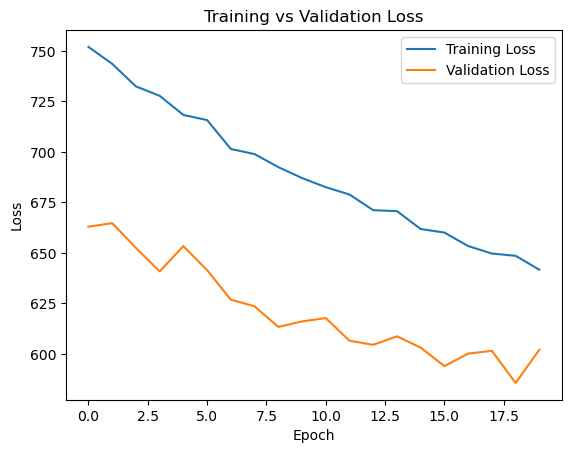

In [63]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

### Model Evalation

In [64]:
test_loss, test_mae = model.evaluate(X_test_rnn, y_test_rnn)

print("Test Loss:", test_loss)
print("Test MAE:", test_mae)

475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 724.4860 - mae: 19.8818
Test Loss: 724.4859619140625
Test MAE: 19.88175392150879


### Price Prediction

#### Using the trained RNN to predict product prices.

In [65]:
y_pred = model.predict(X_test_rnn)
y_pred = y_pred.flatten()

475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


### Performance Metrics 

In [66]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_rnn, y_pred)
mse = mean_squared_error(y_test_rnn, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_rnn, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 19.88175090821921
MSE: 724.4857455488985
RMSE: 26.916272876252734
R² Score: 0.5294311213472871


### The model achieved an R² score of approximately 0.53, meaning it explains about 53% of the variation in product prices

In [67]:
comparison = pd.DataFrame({
    'Actual Price': y_test_rnn,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,27.56,45.622604
1,125.19,57.463779
2,19.67,94.863792
3,25.97,72.318611
4,62.63,73.935249
5,107.36,79.790596
6,71.71,86.568237
7,88.64,71.092644
8,67.65,41.099827
9,78.46,87.596222


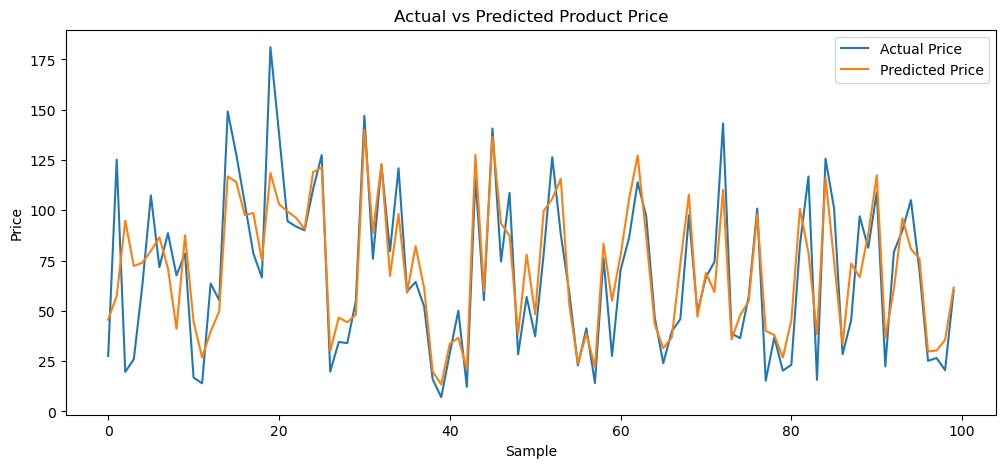

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_rnn[:100], label='Actual Price')
plt.plot(y_pred[:100], label='Predicted Price')

plt.xlabel('Sample')
plt.ylabel('Price')
plt.title('Actual vs Predicted Product Price')
plt.legend()

plt.show()

In [69]:
from sklearn.dummy import DummyRegressor

# Flatten RNN data because DummyRegressor expects 2D input
X_train_baseline = X_train_rnn.reshape(X_train_rnn.shape[0], -1)
X_test_baseline = X_test_rnn.reshape(X_test_rnn.shape[0], -1)

# Create baseline model
baseline_model = DummyRegressor(strategy='mean')

# Train
baseline_model.fit(X_train_baseline, y_train_rnn)

# Predict
baseline_pred = baseline_model.predict(X_test_baseline)

# Baseline metrics
baseline_r2 = r2_score(y_test_rnn, baseline_pred)
baseline_mae = mean_absolute_error(y_test_rnn, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test_rnn, baseline_pred))

print("Baseline Model Performance")
print("R² Score:", baseline_r2)
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

Baseline Model Performance
R² Score: -0.00041516609260039417
MAE: 32.82693925329474
RMSE: 39.24582430179148


In [70]:
print("\n----- MODEL COMPARISON -----")

print("\nBaseline Model:")
print("R² Score:", baseline_r2)
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

print("\nRNN Model:")
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

print("\nR² Improvement:", r2 - baseline_r2)


----- MODEL COMPARISON -----

Baseline Model:
R² Score: -0.00041516609260039417
MAE: 32.82693925329474
RMSE: 39.24582430179148

RNN Model:
R² Score: 0.5294311213472871
MAE: 19.88175090821921
RMSE: 26.916272876252734

R² Improvement: 0.5298462874398875


## Conclusion

#### - The RNN model was developed to predict dynamic product prices using sequential business data.

#### - The model uses previous observations to learn changing pricing patterns and predict the next product price.

#### - The model achieved an **R² score of approximately 0.53**, showing moderate predictive performance.

#### - The model can be further improved through better sequence preparation, hyperparameter tuning and additional pricing factors.